In [1]:
import pya # KLayout Python API
import SiEPIC  # import module for SiEPIC-Tools, helper functions for KLayout
import siepic_ebeam_pdk  # import module for the SiEPIC-EBeam-PDK technology
from SiEPIC.utils.layout import new_layout, floorplan
from SiEPIC.extend import to_itype
from SiEPIC.scripts import connect_cell, connect_pins_with_waveguide


tech_name, top_cell_name = 'EBeam', 'Top'
topcell, ly = new_layout(tech_name, top_cell_name)

# Get Technology
from SiEPIC.utils import get_technology_by_name
TECHNOLOGY = get_technology_by_name(tech_name)

# Optional – FYI only
# Get technology and layer variables
for t in TECHNOLOGY:
    print(f"{t}: {TECHNOLOGY[t]}")

KLayout SiEPIC-Tools version 0.5.31
SiEPIC-Tools is up to date (0.5.31 vs 0.5.31).
Version check, time: 0.4689950942993164 seconds
SiEPIC-EBeam-PDK Python module: siepic_ebeam_pdk, KLayout technology: EBeam
SiEPIC-EBeam-PDK Python module: pymacros, v0.4.53
Libraries associated with Technology EBeam: ['EBeam', 'EBeam-ANT', 'EBeam-Dream', 'EBeam-SiN', 'EBeam_Beta']
technology_name: EBeam
dbu: 0.001
base_path: D:\Hamout\.venv\Lib\site-packages\siepic_ebeam_pdk
INTC_CML: 
INTC_CML_path: 
INTC_CML_version: 
Waveguide: 1/99
Si: 1/0
SiN: 4/0
Si - 90 nm rib: 2/0
Si_Litho193nm: 1/69
Oxide open (to BOX): 6/0
Text: 10/0
Si N: 20/0
Si N++: 24/0
M1_heater: 11/0
M2_router: 12/0
M_Open: 13/0
VC: 40/0
FloorPlan: 99/0
Deep Trench: 201/0
Isolation Trench: 203/0
Dicing: 210/0
Chip design area: 290/0
Keep out: 202/0
SEM: 200/0
DevRec: 68/0
PinRec: 1/10
PinRecM: 1/11
FbrTgt: 81/0
Errors: 999/0
Lumerical: 733/0
BlackBox: 998/0
Laser: 131/155
libraries: ['EBeam']


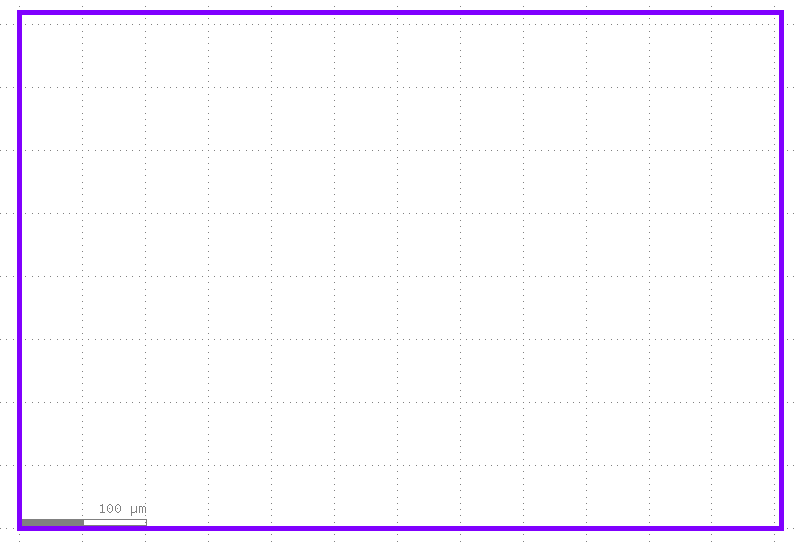

In [2]:
cell, ly = new_layout(tech_name, top_cell_name, GUI=True, overwrite = True)
floorplan(cell, 605e3, 410e3)


# Layer mapping:
LayerSiN = ly.layer(ly.TECHNOLOGY['Si'])
fpLayerN = cell.layout().layer(ly.TECHNOLOGY['FloorPlan'])
TextLayerN = cell.layout().layer(ly.TECHNOLOGY['Text'])

 # Create a sub-cell for our Ring resonator layout
top_cell = cell
dbu = ly.dbu
cell = cell.layout().create_cell("RingResonator")
t = pya.Trans(pya.Trans.R0, 40 / dbu, 14 / dbu)

# place the cell in the top cell
top_cell.insert(pya.CellInstArray(cell.cell_index(), t))

top_cell.plot(width = 400)

In [3]:
 # Configure parameter sweep
pol = 'TE' # Polarization

# Sweep Radius, Coupling Gap
sweep_radius = [3,    5,    5,    5,    10,   10,   10,   10]
sweep_gap    = [0.07, 0.07, 0.08, 0.09, 0.08, 0.09, 0.10, 0.11]
x_offset = 67
wg_bend_radius = 5

wg_width = 0.5

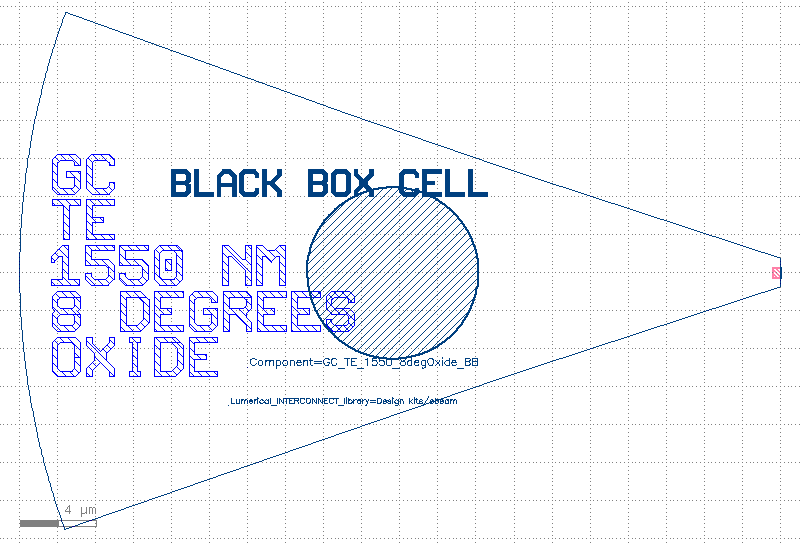

In [4]:
# Import cell from the SiEPIC EBeam Library
from SiEPIC.utils import create_cell2
cell_ebeam_gc = create_cell2(ly, 'GC_TE_1550_8degOxide_BB', 'EBeam')
GC_pitch = 127
gc_length = cell_ebeam_gc.bbox().width()*dbu

cell_ebeam_gc.plot(width=400)

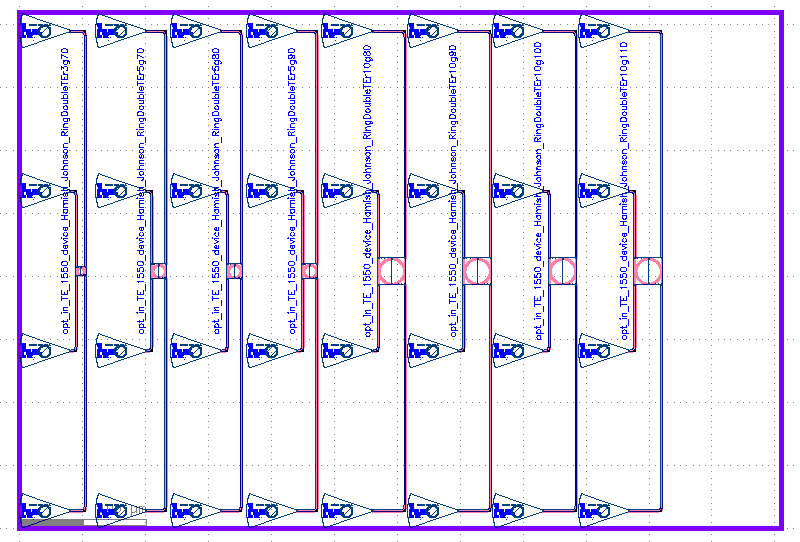

In [6]:
designer_name = 'Hamish_Johnson'

# Loop through the parameter sweep
for i in range(len(sweep_gap)):

    # place layout at location:
    if i==0:
        x=0
    else:
        # next device is placed at the right-most element + length of the grating coupler
        # or 60 microns from the previous grating coupler, whichever is greater
        x = max(inst_dc2.bbox().right*dbu + gc_length + 1, instGCs[0].trans.disp.x*dbu + 60)

    # get the parameters
    r = sweep_radius[i]
    g = sweep_gap[i]

    # Grating couplers, Ports 0, 1, 2, 3 (from the bottom up)
    instGCs = []
    for i in range(0,4):
        t = pya.Trans(pya.Trans.R0, to_itype(x,dbu), i*127/dbu)
        instGCs.append( cell.insert(pya.CellInstArray(cell_ebeam_gc.cell_index(), t)) )

    # Label for automated measurements, laser on Port 2, detectors on Ports 1, 3, 4
    t = pya.Trans(pya.Trans.R90, to_itype(x,dbu), to_itype(GC_pitch*2,dbu))
    text = pya.Text ("opt_in_%s_1550_device_%s_RingDouble%sr%sg%s" % (pol.upper(), designer_name, pol.upper(),r,int(round(g*1000))), t)
    text.halign = 1
    cell.shapes(TextLayerN).insert(text).text_size = 5/dbu

    # Ring resonator from directional coupler PCells
    cell_dc = ly.create_cell("ebeam_dc_halfring_straight", "EBeam", { "r": r, "w": wg_width, "g": g, "bustype": 0 } )
    y_ring = GC_pitch*3/2
    # first directional coupler
    t1 = pya.Trans(pya.Trans.R270, to_itype(x+wg_bend_radius, dbu), to_itype(y_ring, dbu))
    inst_dc1 = cell.insert(pya.CellInstArray(cell_dc.cell_index(), t1))
    # add 2nd directional coupler, snapped to the first one
    inst_dc2 = connect_cell(inst_dc1, 'pin2', cell_dc, 'pin4')

    # Create paths for waveguides, with the type defined in WAVEGUIDES.xml in the PDK
    waveguide_type='Strip TE 1550 nm, w=500 nm'

    # GC1 to bottom-left of ring pin3
    connect_pins_with_waveguide(instGCs[1], 'opt1', inst_dc1, 'pin3', waveguide_type=waveguide_type)

    # GC2 to top-left of ring pin1
    connect_pins_with_waveguide(instGCs[2], 'opt1', inst_dc1, 'pin1', waveguide_type=waveguide_type)

    # GC0 to top-right of ring
    connect_pins_with_waveguide(instGCs[0], 'opt1', inst_dc2, 'pin1', waveguide_type=waveguide_type)

    # GC3 to bottom-right of ring
    connect_pins_with_waveguide(instGCs[3], 'opt1', inst_dc2, 'pin3', waveguide_type=waveguide_type)

top_cell.plot(width = 400)

In [7]:
# 1. Export the layout
from SiEPIC.scripts import export_layout
export_type = 'static'
filename = 'openEBL_' + designer_name + '_ring_OFC2026' # filename
if export_type == 'static':
    # Export for fabrication, removing PCells
    file_out = export_layout(top_cell, '', filename, format='gds', screenshot=True)
else:
    # Export as an editable layout
    import os
    file_out = os.path.join('', filename+'.oas')
    ly.write(file_out)

# # 2. Download the file
# from google.colab import files
# files.download(file_out)
# print(f"File '{file_out}' initiated for download.")

# Ring SFWM

Initiating design 0 at (x, y) = (0.0, 0)
Initiating design 1 at (x, y) = (113.4, 0)


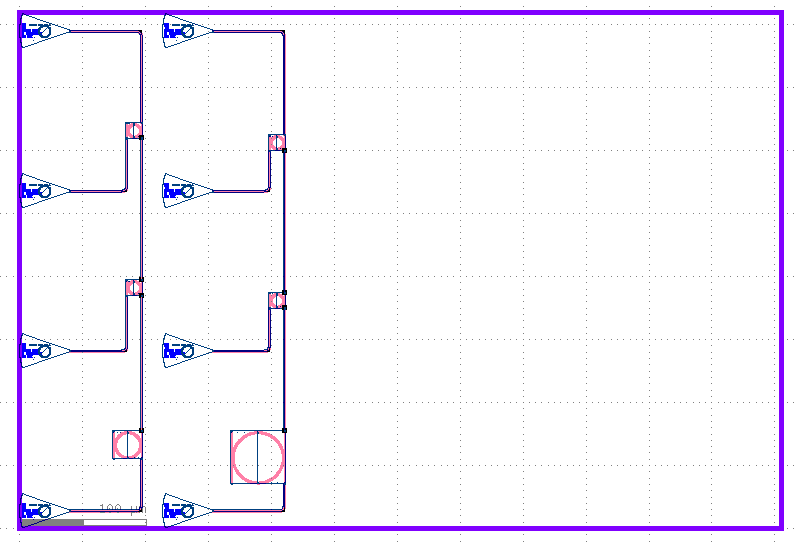

In [59]:
import numpy as np

cell, ly = new_layout(tech_name, top_cell_name, GUI=True, overwrite = True)
floorplan(cell, 605e3, 410e3)

# Layer mapping:
LayerSiN = ly.layer(ly.TECHNOLOGY['Si'])
fpLayerN = cell.layout().layer(ly.TECHNOLOGY['FloorPlan'])
TextLayerN = cell.layout().layer(ly.TECHNOLOGY['Text'])

 # Create a sub-cell for our Ring resonator layout
top_cell = cell
dbu = ly.dbu
cell = cell.layout().create_cell("RingResonator")
t = pya.Trans(pya.Trans.R0, 40 / dbu, 14 / dbu)

# place the cell in the top cell
top_cell.insert(pya.CellInstArray(cell.cell_index(), t))

cell_ebeam_gc = create_cell2(ly, 'GC_TE_1550_8degOxide_BB', 'EBeam')
GC_pitch = 127
gc_length = cell_ebeam_gc.bbox().width()*dbu

# Parametric design
r_arr = [10, 20]  # Main ring radius
g_arr = [0.1, 0.1]  # Coupling gap
w_arr = [0.750, 0.750]  # Waveguide width
r_filter_arr = [5, 5]  # Filter ring radius
g_filter_arr = [0.1, 0.1]  # Filter coupling gap

# Parametrically derived params
margin_dx = 15
min_dx = np.max([ r+g+w, r_filter + g_filter + w ])*2 + margin_dx

dx_next_cell = min_dx*2

# Grating couplers, Ports 0, 1, 2, 3 (from the bottom up)
x=0
y=0

for i, (r, g, w, r_filter, g_filter) in enumerate(zip(r_arr, g_arr, w_arr, r_filter_arr, g_filter_arr)):
    x = i*dx_next_cell
    y = 0
    print(f"Initiating design {i} at (x, y) = ({x}, {y})")
    instGCs = []
    for i in range(0,4):
        t = pya.Trans(pya.Trans.R0, to_itype(x,dbu), i*127/dbu)
        instGCs.append( cell.insert(pya.CellInstArray(cell_ebeam_gc.cell_index(), t)) )

    x += min_dx
    y += 125/2 - r
    # Main ring resonator
    cell_dc = ly.create_cell("ebeam_dc_halfring_straight", "EBeam", { "r": r, "w": w, "g": g, "bustype": 0 } )
    y_ring = GC_pitch*3/2
    # first directional coupler
    t1 = pya.Trans(pya.Trans.R90, to_itype(x, dbu), to_itype(y, dbu))
    inst_dc1 = cell.insert(pya.CellInstArray(cell_dc.cell_index(), t1))
    # add 2nd directional coupler, snapped to the first one
    inst_dc2 = connect_cell(inst_dc1, 'pin2', cell_dc, 'pin4')

    x += 0
    y += 125

    # Filters
    cell_dc_filter = ly.create_cell("ebeam_dc_halfring_straight", "EBeam", { "r": r_filter, "w": w, "g": g_filter, "bustype": 0 } )
    # first directional coupler
    t1 = pya.Trans(pya.Trans.R90, to_itype(x, dbu), to_itype(y, dbu))
    inst_dc1_filter = cell.insert(pya.CellInstArray(cell_dc_filter.cell_index(), t1))
    # add 2nd directional coupler, snapped to the first one
    inst_dc2_filter = connect_cell(inst_dc1_filter, 'pin2', cell_dc_filter, 'pin4')

    x += 0
    y += 125

    # first directional coupler
    t1 = pya.Trans(pya.Trans.R90, to_itype(x, dbu), to_itype(y, dbu))
    inst_dc3_filter = cell.insert(pya.CellInstArray(cell_dc_filter.cell_index(), t1))
    # add 2nd directional coupler, snapped to the first one
    inst_dc4_filter = connect_cell(inst_dc3_filter, 'pin2', cell_dc_filter, 'pin4')

    # Create paths for waveguides, with the type defined in WAVEGUIDES.xml in the PDK
    waveguide_type='Strip TE 1550 nm, w=500 nm'

    connect_pins_with_waveguide(instGCs[0],      'opt1', inst_dc1,        'pin1', waveguide_type=waveguide_type)
    connect_pins_with_waveguide(inst_dc1,        'pin3', inst_dc1_filter, 'pin1', waveguide_type=waveguide_type)
    connect_pins_with_waveguide(inst_dc1_filter, 'pin3', inst_dc3_filter, 'pin1', waveguide_type=waveguide_type)
    connect_pins_with_waveguide(inst_dc3_filter, 'pin3', instGCs[3],      'opt1', waveguide_type=waveguide_type)

    connect_pins_with_waveguide(inst_dc2_filter, 'pin3', instGCs[1],      'opt1', waveguide_type=waveguide_type)
    connect_pins_with_waveguide(inst_dc4_filter, 'pin3', instGCs[2],      'opt1', waveguide_type=waveguide_type)

top_cell.plot(width = 400)